In [ ]:
! pip install scikit-learn==1.6.0 streamlit==1.30.0 pandas==2.0.3 numpy==1.26.4 matplotlib==3.8.2 seaborn==0.12.3 plotly==5.17.0    

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked']]
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [7]:
df.isna().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

In [8]:
df_2 = df.copy()

In [9]:
df_2['age'].fillna(df_2['age'].median(),inplace=True)
df_2['embarked'].fillna(df_2['embarked'].mode()[0],inplace=True)

C:\Users\arezkallah\AppData\Local\Temp\ipykernel_35252\3029234235.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_2['age'].fillna(df_2['age'].median(),inplace=True)
C:\Users\arezkallah\AppData\Local\Temp\ipykernel_35252\3029234235.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [10]:
df_2.isna().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

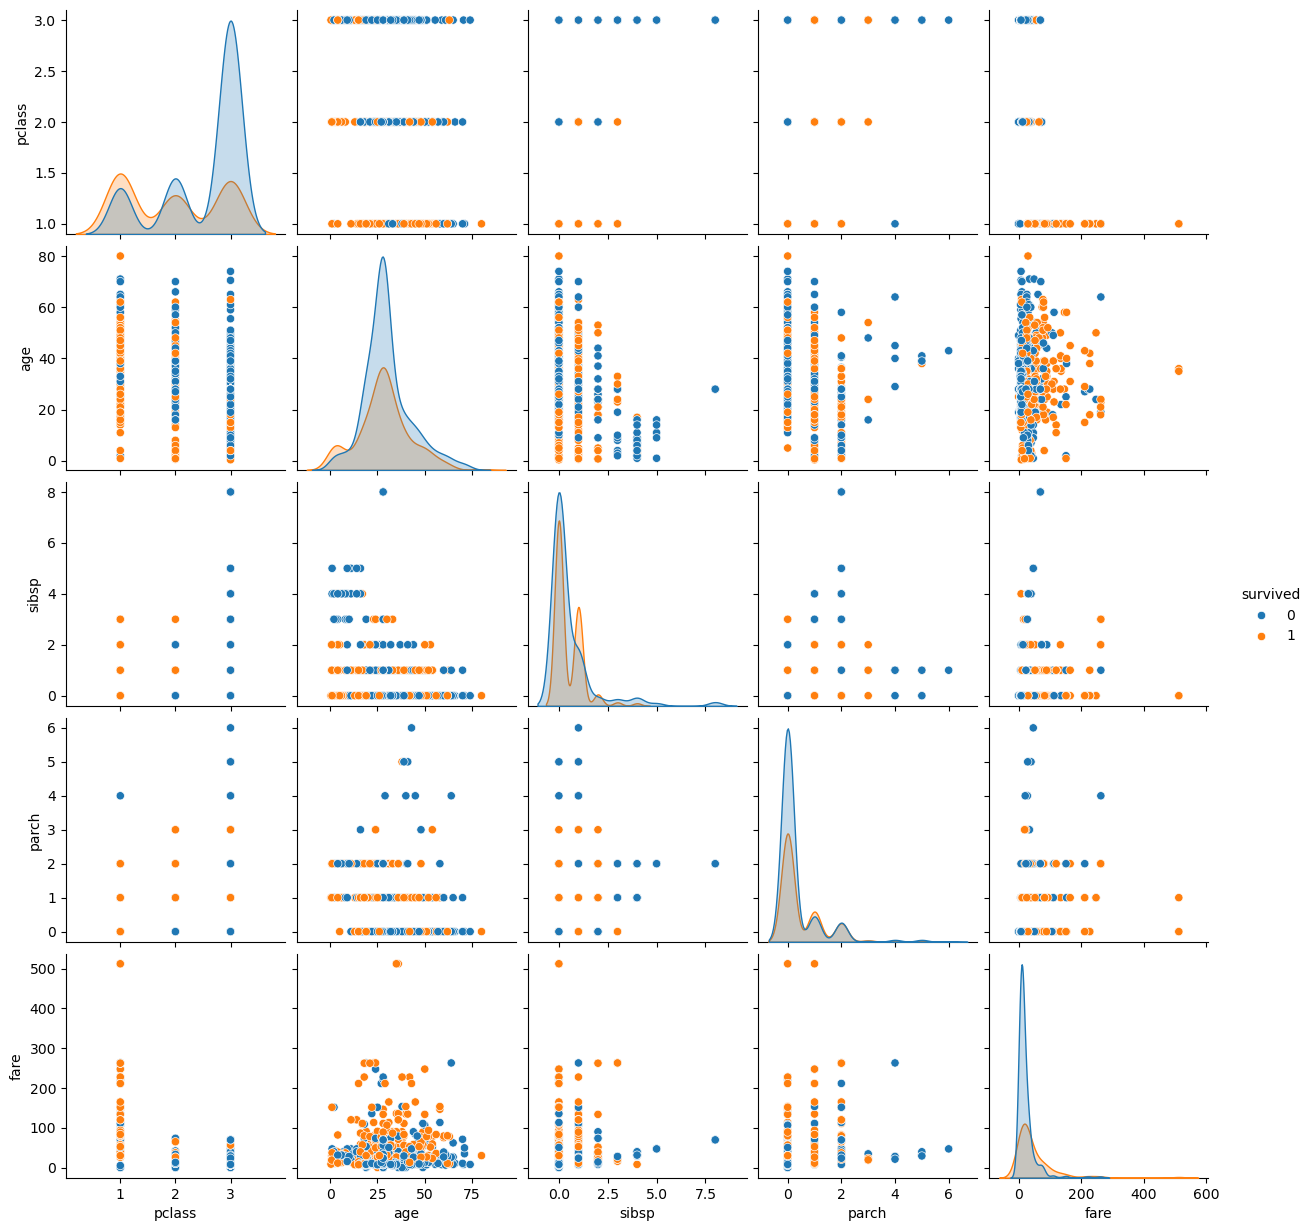

In [11]:
sns.pairplot(data=df_2,hue='survived')

<Axes: xlabel='pclass', ylabel='count'>

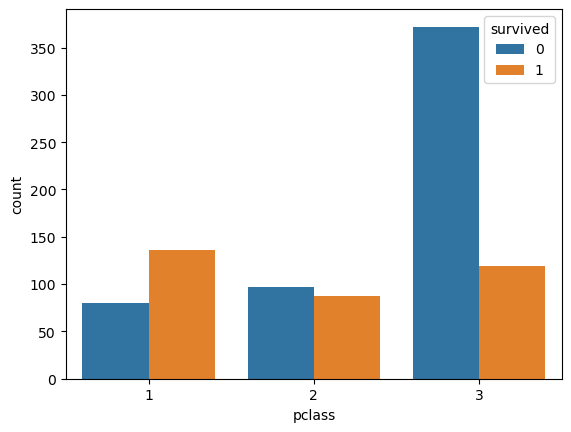

In [12]:
sns.countplot(x = 'pclass',hue='survived', data = df)

<Axes: xlabel='sex', ylabel='count'>

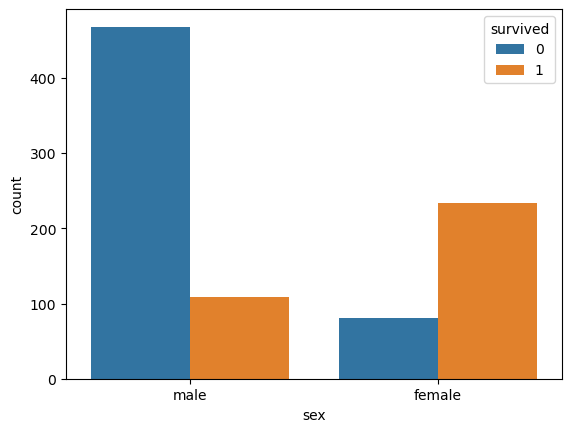

In [13]:
sns.countplot(x = 'sex',hue='survived', data = df)

<Axes: xlabel='pclass', ylabel='count'>

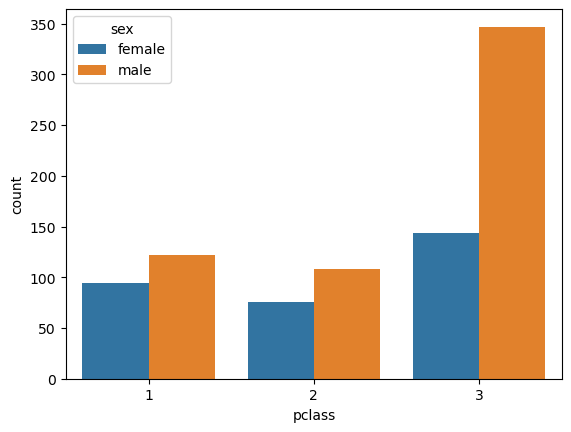

In [14]:
sns.countplot(x = 'pclass',hue='sex', data = df)

<Axes: xlabel='embarked', ylabel='count'>

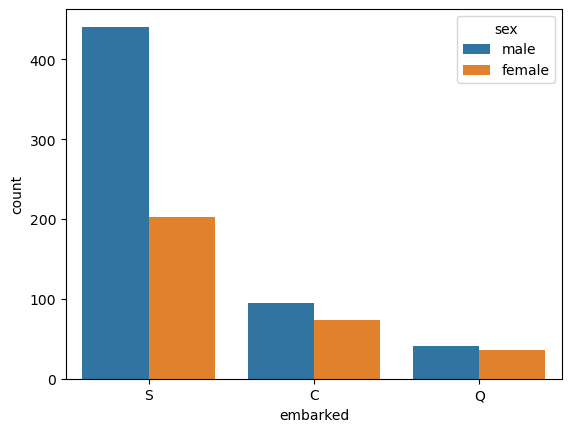

In [15]:
sns.countplot(x = 'embarked',hue='sex', data = df)

<Axes: xlabel='embarked', ylabel='count'>

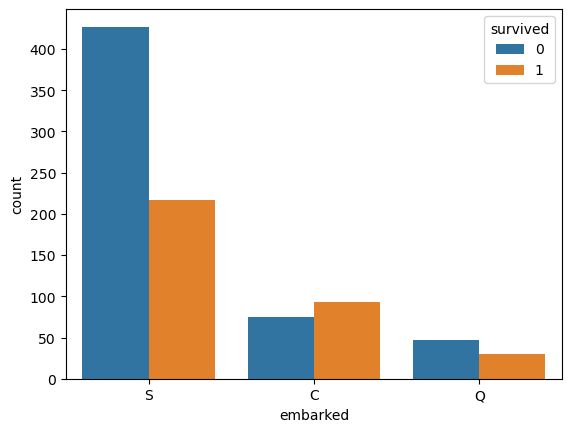

In [16]:
sns.countplot(x = 'embarked',hue='survived', data = df)

## split input and output

In [17]:
X = df_2.drop('survived',axis=1)
y = df_2['survived']

In [18]:
X = pd.get_dummies(X,drop_first=True)

In [19]:
X

,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,True,False,True
887,1,19.0,0,0,30.0000,False,False,True
888,3,28.0,1,2,23.4500,False,False,True
889,1,26.0,0,0,30.0000,True,False,False


## split train test

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42,stratify=y)

## feature selection

In [21]:
from sklearn.feature_selection import mutual_info_classif,SelectKBest
fs = SelectKBest(mutual_info_classif,k='all')
fs = fs.fit(x_train,y_train)
x_train_fs = fs.transform(x_train)
x_test_fs = fs.transform(x_test)

C:\Users\arezkallah\AppData\Local\Temp\ipykernel_35252\4083393397.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[i for i in fs.feature_names_in_],y=fs.scores_,palette='husl')


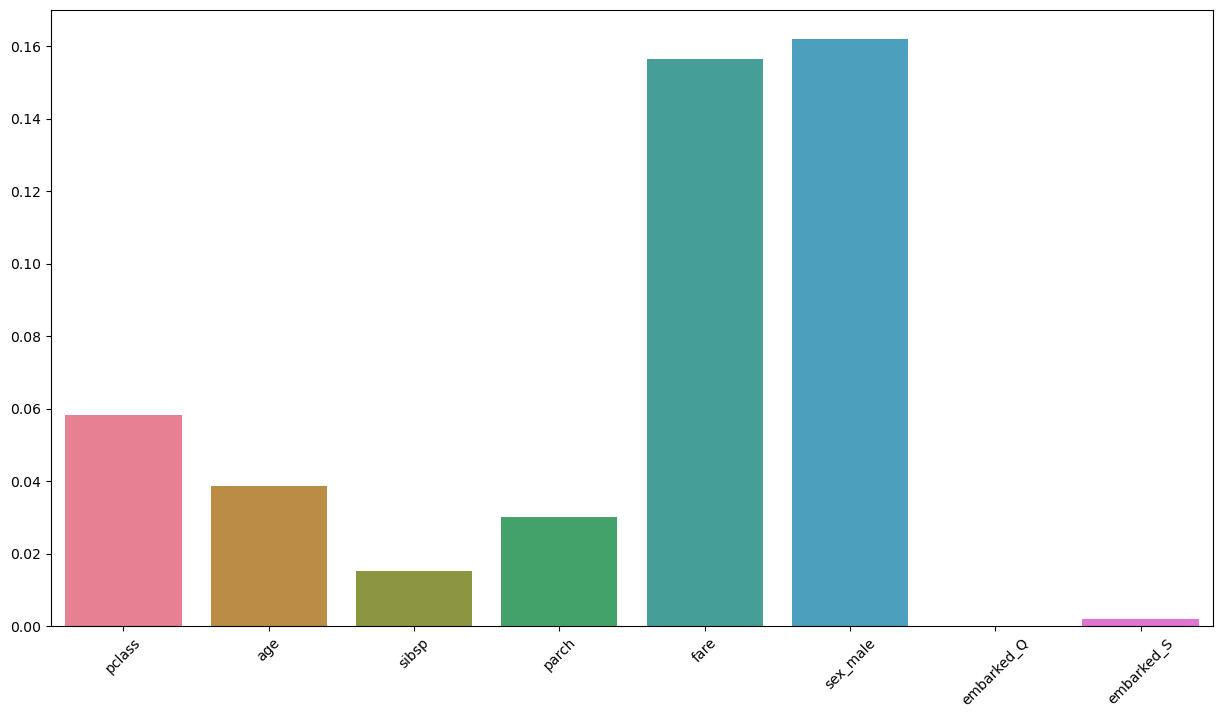

In [22]:
plt.figure(figsize=[15,8])
sns.barplot(x=[i for i in fs.feature_names_in_],y=fs.scores_,palette='husl')
plt.xticks(rotation=45);

In [23]:
fs = SelectKBest(mutual_info_classif,k=5)
fs = fs.fit(x_train,y_train)
x_train_fs = fs.transform(x_train)
x_test_fs = fs.transform(x_test)

In [24]:
x_train_fs = pd.DataFrame(x_train_fs,columns=fs.get_feature_names_out())
x_train_fs

,pclass,age,fare,sex_male,embarked_S
0,3.0,28.0,56.4958,1.0,1.0
1,2.0,28.0,0.0000,1.0,1.0
2,1.0,28.0,221.7792,1.0,1.0
3,3.0,18.0,9.3500,0.0,1.0
4,2.0,31.0,26.2500,0.0,1.0
...,...,...,...,...,...
707,3.0,28.0,7.8792,0.0,0.0
708,1.0,35.0,512.3292,0.0,0.0
709,3.0,48.0,34.3750,0.0,1.0
710,1.0,47.0,38.5000,1.0,1.0


## Scaling

In [25]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train_fs)
x_test_scaled = sc.transform(x_test_fs)

c:\Users\arezkallah\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## modeling

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
lr = LogisticRegression()
lr.fit(x_train_scaled,y_train)
y_pred_lr = lr.predict(x_test_scaled)
print('evaluation for training \n',classification_report(y_train,lr.predict(x_train_scaled)))
print('evaluation for testing \n',classification_report(y_test,y_pred_lr))


evaluation for training 
               precision    recall  f1-score   support

           0       0.83      0.85      0.84       439
           1       0.74      0.71      0.73       273

    accuracy                           0.79       712
   macro avg       0.78      0.78      0.78       712
weighted avg       0.79      0.79      0.79       712

evaluation for testing 
               precision    recall  f1-score   support

           0       0.80      0.84      0.82       110
           1       0.72      0.67      0.69        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179



In [27]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train_scaled,y_train)
y_pred_knn = knn.predict(x_test_scaled)
print('evaluation for training \n',classification_report(y_train,knn.predict(x_train_scaled)))
print('evaluation for testing \n',classification_report(y_test,y_pred_knn))


evaluation for training 
               precision    recall  f1-score   support

           0       0.86      0.92      0.89       439
           1       0.85      0.77      0.81       273

    accuracy                           0.86       712
   macro avg       0.86      0.84      0.85       712
weighted avg       0.86      0.86      0.86       712

evaluation for testing 
               precision    recall  f1-score   support

           0       0.82      0.93      0.87       110
           1       0.85      0.68      0.76        69

    accuracy                           0.83       179
   macro avg       0.84      0.80      0.81       179
weighted avg       0.83      0.83      0.83       179



In [28]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train_scaled,y_train)
y_pred_nb = nb.predict(x_test_scaled)
print('evaluation for training \n',classification_report(y_train,nb.predict(x_train_scaled)))
print('evaluation for testing \n',classification_report(y_test,y_pred_nb))

evaluation for training 
               precision    recall  f1-score   support

           0       0.82      0.85      0.84       439
           1       0.75      0.70      0.72       273

    accuracy                           0.79       712
   macro avg       0.78      0.78      0.78       712
weighted avg       0.79      0.79      0.79       712

evaluation for testing 
               precision    recall  f1-score   support

           0       0.78      0.85      0.81       110
           1       0.72      0.62      0.67        69

    accuracy                           0.76       179
   macro avg       0.75      0.73      0.74       179
weighted avg       0.76      0.76      0.76       179



In [29]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(x_train_scaled,y_train)
y_pred_svm = svm.predict(x_test_scaled)
print('evaluation for training \n',classification_report(y_train,svm.predict(x_train_scaled)))
print('evaluation for testing \n',classification_report(y_test,y_pred_svm))

evaluation for training 
               precision    recall  f1-score   support

           0       0.81      0.95      0.87       439
           1       0.90      0.63      0.74       273

    accuracy                           0.83       712
   macro avg       0.85      0.79      0.81       712
weighted avg       0.84      0.83      0.82       712

evaluation for testing 
               precision    recall  f1-score   support

           0       0.79      0.95      0.86       110
           1       0.87      0.59      0.71        69

    accuracy                           0.81       179
   macro avg       0.83      0.77      0.78       179
weighted avg       0.82      0.81      0.80       179



In [30]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train_scaled,y_train)
y_pred_dt = dt.predict(x_test_scaled)
print('evaluation for training \n',classification_report(y_train,dt.predict(x_train_scaled)))
print('evaluation for testing \n',classification_report(y_test,y_pred_dt))

evaluation for training 
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       439
           1       0.99      0.96      0.97       273

    accuracy                           0.98       712
   macro avg       0.98      0.98      0.98       712
weighted avg       0.98      0.98      0.98       712

evaluation for testing 
               precision    recall  f1-score   support

           0       0.85      0.86      0.86       110
           1       0.78      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [31]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train_scaled,y_train)
y_pred_rf = rf.predict(x_test_scaled)
print('evaluation for training \n',classification_report(y_train,rf.predict(x_train_scaled)))
print('evaluation for testing \n',classification_report(y_test,y_pred_rf))

evaluation for training 
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       439
           1       0.98      0.96      0.97       273

    accuracy                           0.98       712
   macro avg       0.98      0.98      0.98       712
weighted avg       0.98      0.98      0.98       712

evaluation for testing 
               precision    recall  f1-score   support

           0       0.85      0.88      0.87       110
           1       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



## cross validation

In [32]:
from sklearn.model_selection import KFold,cross_validate
kfold = KFold(n_splits=10)
scores = cross_validate(rf,x_train_scaled,y_train,cv=kfold)
scores

{'fit_time': array([0.13621473, 0.14735699, 0.14723516, 0.22305417, 0.15105748,
        0.12680531, 0.12503409, 0.11612892, 0.13399196, 0.12474895]),
 'score_time': array([0.00524712, 0.00989652, 0.00662398, 0.00948668, 0.00683808,
        0.00861716, 0.0053761 , 0.00464201, 0.00533843, 0.0049367 ]),
 'test_score': array([0.75      , 0.83333333, 0.8028169 , 0.66197183, 0.81690141,
        0.81690141, 0.87323944, 0.83098592, 0.83098592, 0.84507042])}

In [33]:
scores['test_score'].mean()

np.float64(0.8062206572769954)

## hyper parameter tuning

In [34]:
from sklearn.model_selection import GridSearchCV
parameters = {'n_estimators':[100,200,300,500],'max_depth':[4,5,7,9]}
grid_search = GridSearchCV(rf,param_grid=parameters,cv=5)
grid_search.fit(x_train_scaled,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [4, 5, 7, 9],
                         'n_estimators': [100, 200, 300, 500]})

In [35]:
grid_search.best_params_

{'max_depth': 4, 'n_estimators': 300}

In [36]:
final_rf_model = RandomForestClassifier(n_estimators=100,max_depth= 3)
final_rf_model.fit(x_train_scaled,y_train)
y_pred_rf = final_rf_model.predict(x_test_scaled)
print('evaluation for training \n',classification_report(y_train,final_rf_model.predict(x_train_scaled)))
print('evaluation for testing \n',classification_report(y_test,y_pred_rf))

evaluation for training 
               precision    recall  f1-score   support

           0       0.83      0.93      0.88       439
           1       0.86      0.69      0.77       273

    accuracy                           0.84       712
   macro avg       0.85      0.81      0.82       712
weighted avg       0.84      0.84      0.83       712

evaluation for testing 
               precision    recall  f1-score   support

           0       0.77      0.90      0.83       110
           1       0.78      0.57      0.66        69

    accuracy                           0.77       179
   macro avg       0.77      0.73      0.74       179
weighted avg       0.77      0.77      0.76       179



## start pipline

In [37]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [38]:
X = df.drop('survived',axis=1)
y = df['survived']

In [39]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [40]:
numeric_columns= x_train.select_dtypes(exclude='object').columns
numeric_columns

Index(['pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')

In [41]:
cat_columns = x_train.select_dtypes(include='object').columns
cat_columns

Index(['sex', 'embarked'], dtype='object')

In [42]:
X['sex'].unique()

array(['male', 'female'], dtype=object)

In [43]:
X['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
numerical_pipline = Pipeline(steps=[('handle missing value',SimpleImputer(strategy='median')),
                                   ('scaling',StandardScaler(with_mean=False))])

In [45]:
cat_pipline = Pipeline(steps=[('handle missing value',SimpleImputer(strategy='most_frequent')),
                             ('one hot encoder',OneHotEncoder(drop='first')),
                             ('scaling',StandardScaler(with_mean=False))])

In [46]:
from sklearn.compose import ColumnTransformer
preprocessing = ColumnTransformer(transformers=[('numerical_columns',numerical_pipline,numeric_columns),
                                               ('cat_columns',cat_pipline,cat_columns)],remainder="passthrough")
preprocessing

ColumnTransformer(remainder='passthrough',
                  transformers=[('numerical_columns',
                                 Pipeline(steps=[('handle missing value',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaling',
                                                  StandardScaler(with_mean=False))]),
                                 Index(['pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')),
                                ('cat_columns',
                                 Pipeline(steps=[('handle missing value',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('one hot encoder',
                                                  OneHotEncoder(drop='first')),
                                                 ('scaling',
                                                  StandardScaler(with_mean=False))]),
                                 Index(['sex', 'embarked'], dtype='object'))])

In [47]:
final_pipeline = Pipeline(steps=[('preprocessing',preprocessing),
                                ('modeling',RandomForestClassifier(n_estimators=100,max_depth= 3))])
final_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical_columns',
                                                  Pipeline(steps=[('handle '
                                                                   'missing '
                                                                   'value',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaling',
                                                                   StandardScaler(with_mean=False))]),
                                                  Index(['pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')),
                                                 ('cat_columns',
                                                  Pipeline(steps=[('handle '
                                                                   'missing '
                                                                   'value',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one hot '
                                                                   'encoder',
                                                                   OneHotEncoder(drop='first')),
                                                                  ('scaling',
                                                                   StandardScaler(with_mean=False))]),
                                                  Index(['sex', 'embarked'], dtype='object'))])),
                ('modeling', RandomForestClassifier(max_depth=3))])

In [48]:
x_train

,pclass,sex,age,sibsp,parch,fare,embarked
692,3,male,NaN,0,0,56.4958,S
481,2,male,NaN,0,0,0.0000,S
527,1,male,NaN,0,0,221.7792,S
855,3,female,18.0,0,1,9.3500,S
801,2,female,31.0,1,1,26.2500,S
...,...,...,...,...,...,...,...
359,3,female,NaN,0,0,7.8792,Q
258,1,female,35.0,0,0,512.3292,C
736,3,female,48.0,1,3,34.3750,S
462,1,male,47.0,0,0,38.5000,S


In [49]:
final_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical_columns',
                                                  Pipeline(steps=[('handle '
                                                                   'missing '
                                                                   'value',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaling',
                                                                   StandardScaler(with_mean=False))]),
                                                  Index(['pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')),
                                                 ('cat_columns',
                                                  Pipeline(steps=[('handle '
                                                                   'missing '
                                                                   'value',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one hot '
                                                                   'encoder',
                                                                   OneHotEncoder(drop='first')),
                                                                  ('scaling',
                                                                   StandardScaler(with_mean=False))]),
                                                  Index(['sex', 'embarked'], dtype='object'))])),
                ('modeling', RandomForestClassifier(max_depth=3))])

In [50]:
y_pred_final = final_pipeline.predict(x_test)

In [51]:
y_pred_final

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [52]:
import joblib
joblib.dump(final_pipeline,'titanic.pkl')

['titanic.pkl']

In [53]:
classifier = joblib.load('titanic.pkl')

In [54]:
prediction = classifier.predict(pd.DataFrame({'pclass':[1],'sex':['female'],'age':[23],'sibsp':[0],'parch':[1],'fare':[50],'embarked':['S']}))
prediction

array([1])

In [55]:
x_train

,pclass,sex,age,sibsp,parch,fare,embarked
692,3,male,NaN,0,0,56.4958,S
481,2,male,NaN,0,0,0.0000,S
527,1,male,NaN,0,0,221.7792,S
855,3,female,18.0,0,1,9.3500,S
801,2,female,31.0,1,1,26.2500,S
...,...,...,...,...,...,...,...
359,3,female,NaN,0,0,7.8792,Q
258,1,female,35.0,0,0,512.3292,C
736,3,female,48.0,1,3,34.3750,S
462,1,male,47.0,0,0,38.5000,S


In [56]:
%%writefile titanic.py
import pandas as pd
import numpy as np
import joblib
import streamlit as st

classifier = joblib.load('titanic.pkl')

def predict_survived(pclass,sex,age,sibsp,parch,fare,embarked):

    prediction = classifier.predict(pd.DataFrame({'pclass':[pclass],'sex':[sex],'age':[age],'sibsp':[sibsp],'parch':[parch],'fare':[fare],'embarked':[embarked]}))

    label = ['unsurvived','survived']

    return label[prediction[0]]


def main():
    st.title('Titanic prediction')
    html_temp="""
                <div style="background-color:red">
                <h2 style="color:white;text-align:center;">this our streamlit Deployment App</h2>
                </div>
              """
    st.markdown(html_temp,unsafe_allow_html=True)

    pclass = st.text_input('pclass','tell me your passenger class')
    sex = st.radio('pick your gender',['male', 'female'])
    age = st.text_input('age','put your age')
    sibsp = st.text_input('sibsp','put your sibsp')
    parch = st.text_input('parch','put your parch')
    fare = st.text_input('fare','put your fare')
    embarked = st.radio('pick your embarked',['S', 'C', 'Q'])

    result =""

    if st.button('predict'):
        result = predict_survived(pclass,sex,age,sibsp,parch,fare,embarked)
    st.success('this person is {}'.format(result))


if __name__ =='__main__':
    main()






Overwriting titanic.py


In [57]:
! streamlit run titanic.py

^C
